# 05 Progress Visualizations

Creates presentation-ready matplotlib figures for the completed Phase 1 workflow and saves them to `results/figures/`.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from dataset_loader import create_subject_metadata, scan_eeg_files
from feature_extraction import compute_welch_psd
from preprocessing import preprocess_subject
from utils import FIGURES_DIR, METADATA_DIR, RAW_DATASET_DIR

In [2]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
total_eeg_files = len(scan_eeg_files(RAW_DATASET_DIR))
metadata_df = create_subject_metadata(RAW_DATASET_DIR, verbose=False)
summary_path = METADATA_DIR / 'psd_feature_summary.csv'
summary_df = pd.read_csv(summary_path) if summary_path.exists() else pd.DataFrame()
sample_row = metadata_df.iloc[0]
preprocessed = preprocess_subject(sample_row['eeg_file'])
epoch_array = preprocessed['epoch_array']
psd_features, freqs = compute_welch_psd(epoch_array, sfreq=preprocessed['raw'].info['sfreq'])

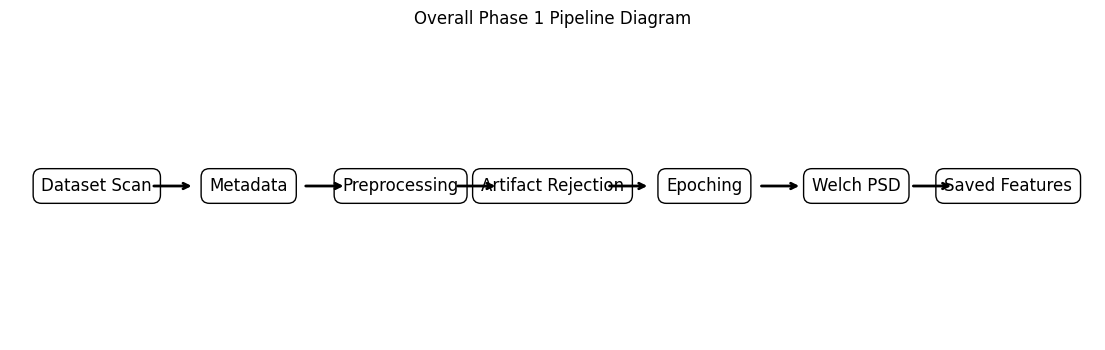

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')
steps = ['Dataset Scan', 'Metadata', 'Preprocessing', 'Artifact Rejection', 'Epoching', 'Welch PSD', 'Saved Features']
x_positions = np.linspace(0.08, 0.92, len(steps))
for x, step in zip(x_positions, steps):
    ax.text(x, 0.5, step, ha='center', va='center', fontsize=12, bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='black'))
for start, end in zip(x_positions[:-1], x_positions[1:]):
    ax.annotate('', xy=(end - 0.05, 0.5), xytext=(start + 0.05, 0.5), arrowprops=dict(arrowstyle='->', lw=2))
ax.set_title('Overall Phase 1 Pipeline Diagram')
fig.savefig(FIGURES_DIR / '01_pipeline_diagram.png', dpi=200, bbox_inches='tight')
plt.show()

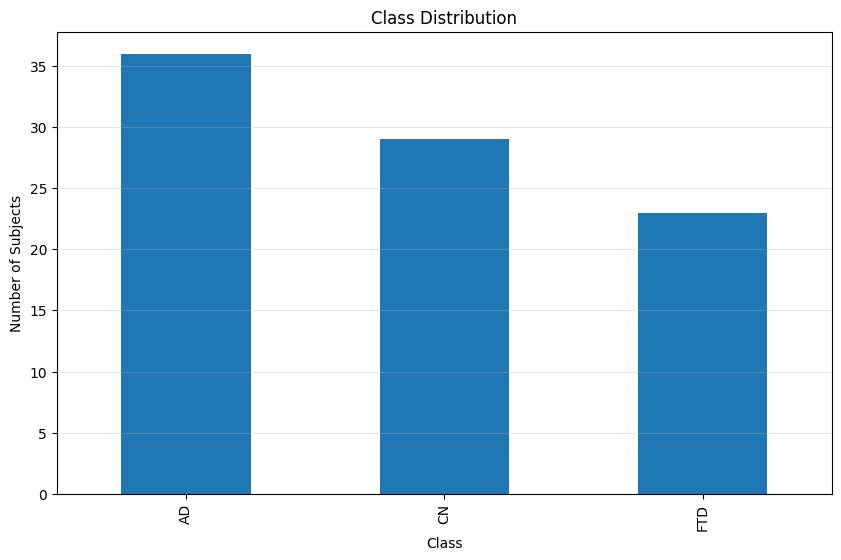

In [4]:
class_counts = metadata_df['class_name'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 6))
class_counts.plot(kind='bar', ax=ax)
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Number of Subjects')
ax.grid(True, axis='y', alpha=0.3)
fig.savefig(FIGURES_DIR / '02_class_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

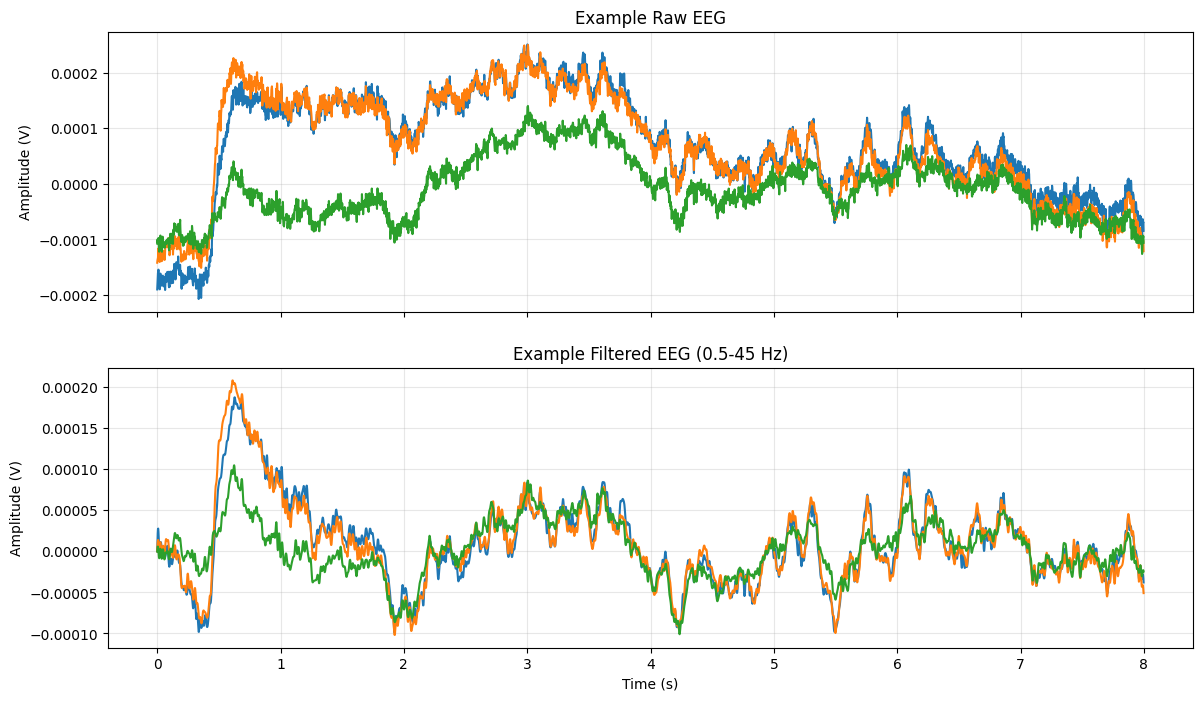

In [5]:
raw = preprocessed['raw']
filtered = preprocessed['filtered']
times = raw.times[:int(raw.info['sfreq'] * 8)]
raw_data, _ = raw[:3, :len(times)]
filtered_data, _ = filtered[:3, :len(times)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(times, raw_data.T)
axes[0].set_title('Example Raw EEG')
axes[0].set_ylabel('Amplitude (V)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(times, filtered_data.T)
axes[1].set_title('Example Filtered EEG (0.5-45 Hz)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (V)')
axes[1].grid(True, alpha=0.3)
fig.savefig(FIGURES_DIR / '03_raw_vs_filtered_eeg.png', dpi=200, bbox_inches='tight')
plt.show()

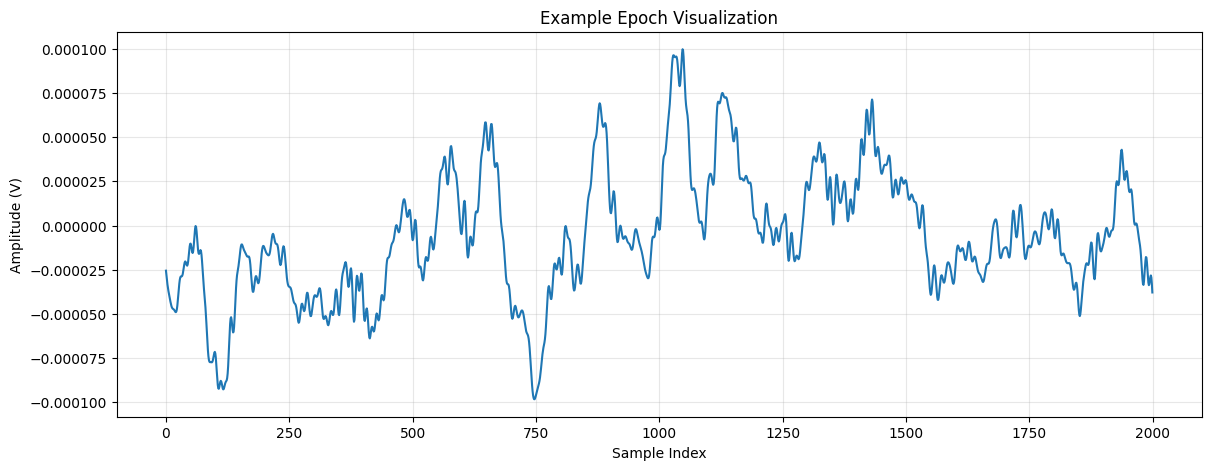

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(epoch_array[0, 0])
ax.set_title('Example Epoch Visualization')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Amplitude (V)')
ax.grid(True, alpha=0.3)
fig.savefig(FIGURES_DIR / '04_example_epoch.png', dpi=200, bbox_inches='tight')
plt.show()

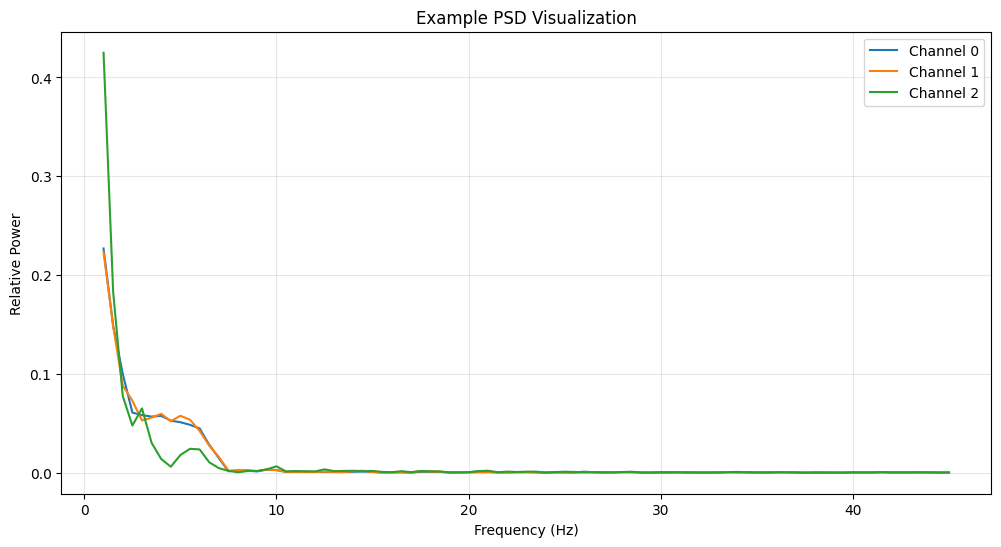

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for channel_idx in range(min(3, psd_features.shape[1])):
    ax.plot(freqs, psd_features[0, channel_idx], label=f'Channel {channel_idx}')
ax.set_title('Example PSD Visualization')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Relative Power')
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(FIGURES_DIR / '05_example_psd.png', dpi=200, bbox_inches='tight')
plt.show()

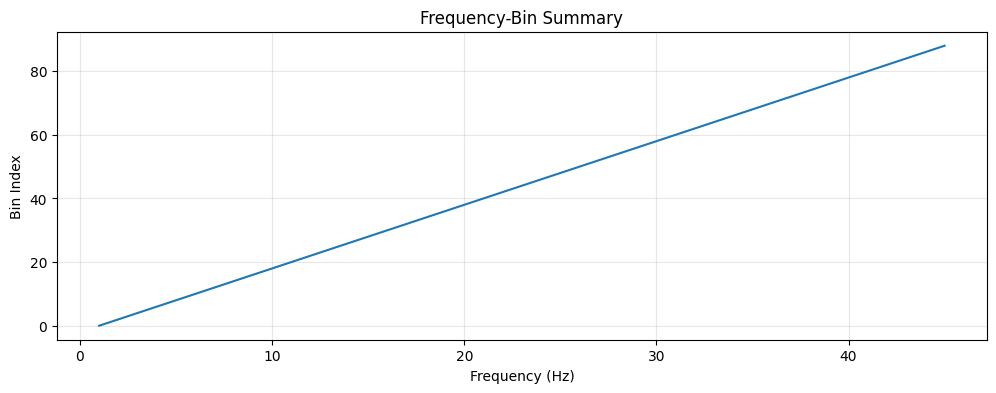

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(freqs, np.arange(len(freqs)))
ax.set_title('Frequency-Bin Summary')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Bin Index')
ax.grid(True, alpha=0.3)
fig.savefig(FIGURES_DIR / '06_frequency_bin_summary.png', dpi=200, bbox_inches='tight')
plt.show()

## EEG Frequency Bands Explanation

- Delta: 0-4 Hz
- Theta: 4-8 Hz
- Alpha: 8-13 Hz
- Beta: 13-30 Hz

EEG signals are analyzed in the frequency domain because different frequency bands are linked to different brain activities. PSD helps show how signal power is distributed across these bands, which makes these patterns useful for Alzheimer-related disease detection.

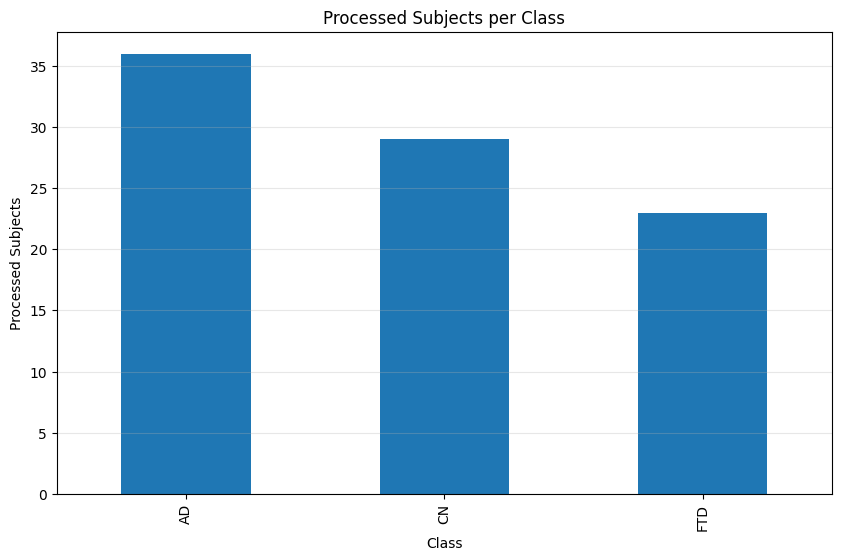

In [9]:
if not summary_df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    summary_df.groupby('class_name')['subject_id'].count().sort_index().plot(kind='bar', ax=ax)
    ax.set_title('Processed Subjects per Class')
    ax.set_xlabel('Class')
    ax.set_ylabel('Processed Subjects')
    ax.grid(True, axis='y', alpha=0.3)
    fig.savefig(FIGURES_DIR / '07_processed_subjects_per_class.png', dpi=200, bbox_inches='tight')
    plt.show()

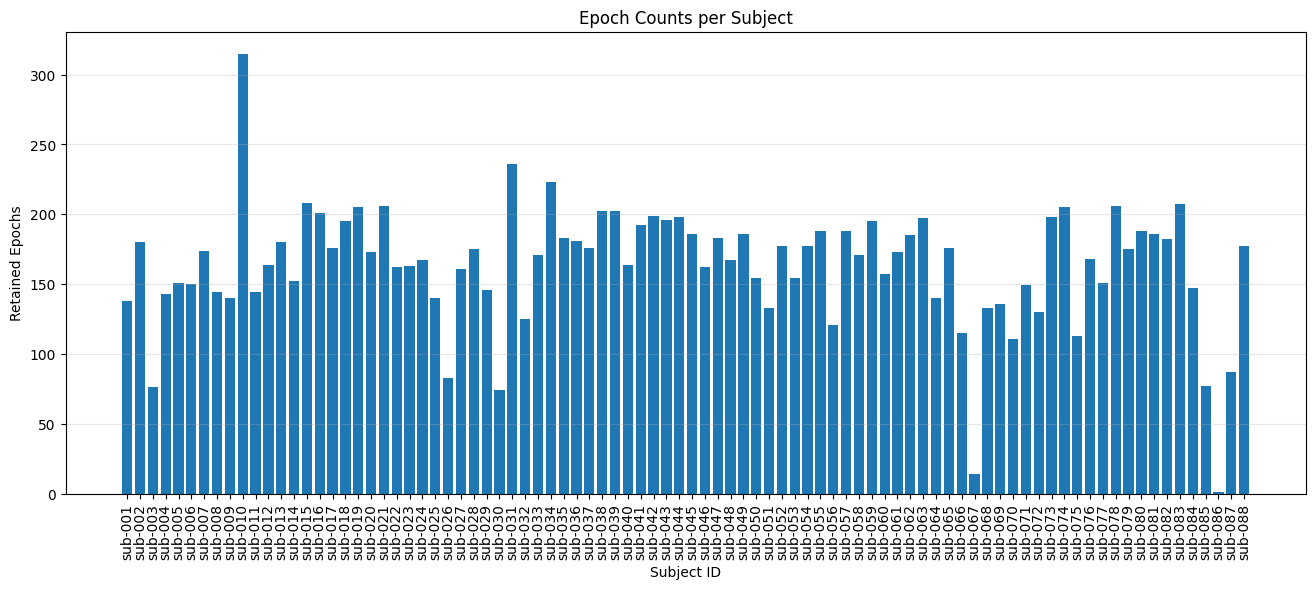

In [10]:
if not summary_df.empty:
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.bar(summary_df['subject_id'], summary_df['n_epochs'])
    ax.set_title('Epoch Counts per Subject')
    ax.set_xlabel('Subject ID')
    ax.set_ylabel('Retained Epochs')
    ax.tick_params(axis='x', rotation=90)
    ax.grid(True, axis='y', alpha=0.3)
    fig.savefig(FIGURES_DIR / '08_epoch_counts_per_subject.png', dpi=200, bbox_inches='tight')
    plt.show()

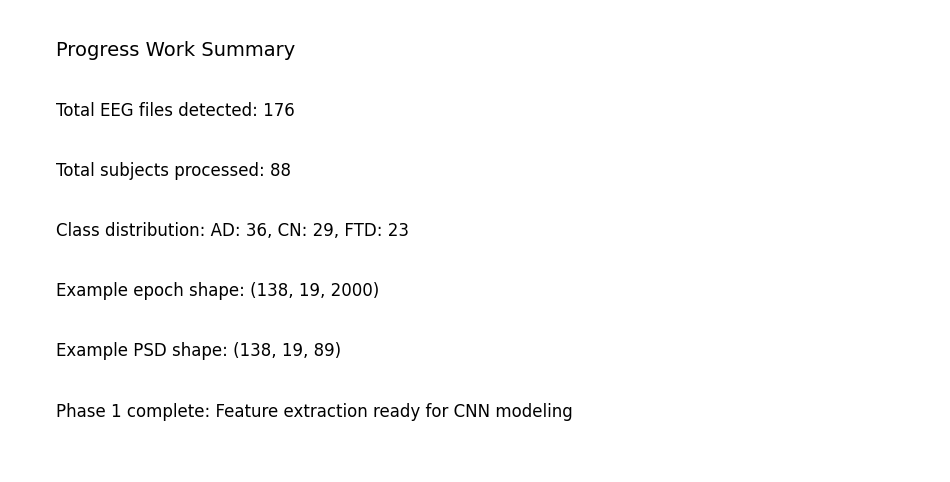

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
class_distribution_text = ', '.join([f"{cls}: {count}" for cls, count in metadata_df['class_name'].value_counts().sort_index().items()])
summary_lines = [
    'Progress Work Summary',
    f'Total EEG files detected: {total_eeg_files}',
    f'Total subjects processed: {len(summary_df)}',
    f'Class distribution: {class_distribution_text}',
    f'Example epoch shape: {epoch_array.shape}',
    f'Example PSD shape: {psd_features.shape}',
    'Phase 1 complete: Feature extraction ready for CNN modeling',
]
for idx, line in enumerate(summary_lines):
    ax.text(0.05, 0.9 - idx * 0.13, line, fontsize=14 if idx == 0 else 12)
fig.savefig(FIGURES_DIR / '09_progress_work_summary.png', dpi=200, bbox_inches='tight')
plt.show()